# Question 2 : Image Colourization using CNNs

### Imports and Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import wandb
import os
from typing import Tuple, List
import random
import matplotlib.pyplot as plt
import glob

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Some preliminary code
def add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

def print_separator() -> None:
    print("="*50)

Using device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
CUDA Version: 12.4


### Load Centroids

In [2]:
color_centroids = np.load('color_centroids.npy')
print(f"Loaded color centroids. Shape: {color_centroids.shape}")

# Print a few centroids
print("Sample color centroids (first 5):")
print(color_centroids[:5])

Loaded color centroids. Shape: (24, 3)
Sample color centroids (first 5):
[[159.64539  160.74811  158.41069 ]
 [ 38.253784  36.082985  30.844734]
 [ 99.041245  97.35045   88.56206 ]
 [215.22934  217.05945  217.59091 ]
 [154.79019  143.68999  111.636345]]


### Dataset Class

In [3]:
class CIFAR10ColorizationDataset(Dataset):
    """
    Custom dataset for CIFAR-10 colorization task.
    Returns grayscale image and corresponding color class labels.
    OPTIMIZED VERSION: Vectorized pre-computation for massive speedup.
    FIXED: Supports indices parameter to avoid data leakage.
    """
    
    def __init__(self, root='./data', train=True, color_centroids=None, transform=None, indices=None):
        """
        Args:
            root: Root directory for CIFAR-10 data
            train: Whether to use training or test split
            color_centroids: Numpy array of shape [24, 3] containing RGB centroids
            transform: Optional transform to apply (for augmentation)
            indices: Optional list of indices to use (for train/val split). If None, uses all data.
        """
        self.cifar_data = CIFAR10(root=root, train=train, download=True)
        self.color_centroids = torch.from_numpy(color_centroids).float()
        self.transform = transform
        self.train = train
        self.indices = indices if indices is not None else list(range(len(self.cifar_data)))
        
        split_name = 'training' if train else 'test'
        if indices is not None:
            split_name += f' (subset of {len(indices)} images)'
        
        print(f"Pre-computing color labels for {split_name}...")
        print("Using optimized vectorized implementation...")
        
        # Load only the images we need [N_subset, 32, 32, 3]
        all_images = torch.from_numpy(self.cifar_data.data[self.indices]).float()
        N = len(all_images)
        
        # Reshape to [N*32*32, 3] for batch processing
        all_pixels = all_images.reshape(-1, 3)
        
        # Process in batches to avoid memory issues
        batch_size = 100000  # Process 100k pixels at a time
        all_labels = []
        
        print(f"Processing {len(all_pixels)} pixels in batches of {batch_size}...")
        for i in range(0, len(all_pixels), batch_size):
            batch = all_pixels[i:i+batch_size]
            # Use torch.cdist for optimized distance computation
            distances = torch.cdist(batch, self.color_centroids)
            labels = torch.argmin(distances, dim=1)
            all_labels.append(labels)
        
        # Reshape back to [N, 32, 32]
        all_labels = torch.cat(all_labels).reshape(N, 32, 32)
        self.precomputed_labels = [all_labels[i] for i in range(N)]
        
        print(f"Pre-computation complete for {N} images.")
        
    def rgb_to_grayscale(self, img):
        """Convert RGB image to grayscale using luminosity method"""
        # img shape: [H, W, 3]
        gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
        return gray
    
    def _assign_color_labels(self, img):
        """
        Assign each pixel to nearest color centroid.
        OPTIMIZED: Uses torch.cdist for faster distance computation.
        
        Args:
            img: numpy array [H, W, 3]
        Returns:
            labels: tensor [H, W] with values in {0, ..., 23}
        """
        H, W, _ = img.shape
        img_flat = img.reshape(-1, 3)  # [H*W, 3]
        img_tensor = torch.from_numpy(img_flat).float()
        
        # OPTIMIZED: Use torch.cdist instead of manual distance computation
        distances = torch.cdist(img_tensor, self.color_centroids)
        
        # Find nearest centroid
        labels = torch.argmin(distances, dim=1)  # [H*W]
        labels = labels.reshape(H, W)  # [H, W]
        
        return labels
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        """
        Returns:
            gray_img: tensor [1, 32, 32] - normalized grayscale image
            color_labels: tensor [32, 32] - color class labels
            rgb_img: tensor [3, 32, 32] - original RGB image (for visualization)
        """
        # FIXED: Map idx to actual CIFAR-10 index
        actual_idx = self.indices[idx]
        img, _ = self.cifar_data[actual_idx]
        img_np = np.array(img)  # [32, 32, 3]
        
        # Apply augmentation if specified and training
        if self.transform is not None and self.train:
            # Convert to PIL for transforms
            img_pil = Image.fromarray(img_np)
            img_pil = self.transform(img_pil)
            img_np = np.array(img_pil)
            # Recompute labels only when augmented (unavoidable)
            color_labels = self._assign_color_labels(img_np)
        else:
            # Use pre-computed labels (fast path)
            # idx is already correct since precomputed_labels is indexed by subset idx
            color_labels = self.precomputed_labels[idx]
        
        # Create grayscale image
        gray_np = self.rgb_to_grayscale(img_np)  # [32, 32]
        
        # Normalize grayscale to [0, 1]
        gray_tensor = torch.from_numpy(gray_np).float() / 255.0
        gray_tensor = gray_tensor.unsqueeze(0)  # [1, 32, 32]
        
        # Convert RGB image to tensor for visualization
        rgb_tensor = torch.from_numpy(img_np).float().permute(2, 0, 1) / 255.0  # [3, 32, 32]
        
        return gray_tensor, color_labels, rgb_tensor

### Experiment to test the difference between regular averaging and luminosity basesd weighted averaging to convert an RGB image to grayscale

Original image shape: (2160, 3840, 3)
Image dtype: uint8
CONVERSION METHODS:

1. Simple Averaging:
   Formula: (R + G + B) / 3
   Equal weight to all channels

2. Perceptual (Luminosity) Method:
   Formula: 0.299*R + 0.587*G + 0.114*B
   Coefficients:
   - Red:   0.299 (30% weight)
   - Green: 0.587 (59% weight)
   - Blue:  0.114 (11% weight)

   Why these weights?
   - Human eyes are most sensitive to green light
   - Moderately sensitive to red
   - Least sensitive to blue


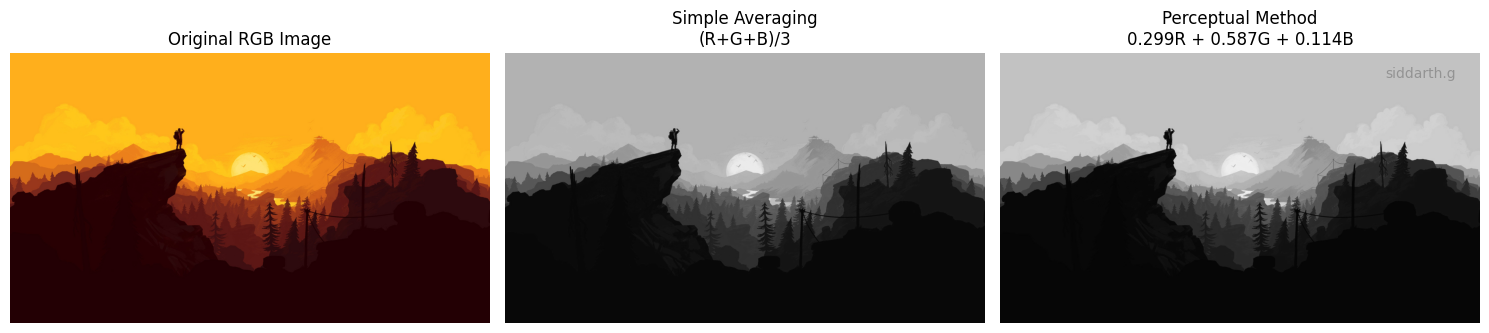


Average difference between methods: 14.58 (out of 255)
Max difference: 45


In [4]:
def load_and_convert_to_grayscale(image_path):
    """
    Load an RGB image and convert it to grayscale using two methods:
    1. Simple averaging
    2. Perceptually-weighted (luminosity method)
    """
    # Load the image
    img = Image.open(image_path)
    rgb_array = np.array(img)
    
    print(f"Original image shape: {rgb_array.shape}")
    print(f"Image dtype: {rgb_array.dtype}")
    
    # Method 1: Simple averaging
    # Just average the R, G, B channels
    grayscale_simple = rgb_array.mean(axis=2).astype(np.uint8)
    
    # Method 2: Perceptually-weighted (luminosity method)
    # Human eyes are more sensitive to green, then red, then blue
    # Standard coefficients: R=0.299, G=0.587, B=0.114
    r_weight = 0.299
    g_weight = 0.587
    b_weight = 0.114
    
    grayscale_perceptual = (
        rgb_array[:, :, 0] * r_weight +
        rgb_array[:, :, 1] * g_weight +
        rgb_array[:, :, 2] * b_weight
    ).astype(np.uint8)
    
    print_separator()
    print("CONVERSION METHODS:")
    print_separator()
    print("\n1. Simple Averaging:")
    print("   Formula: (R + G + B) / 3")
    print("   Equal weight to all channels")
    
    print("\n2. Perceptual (Luminosity) Method:")
    print(f"   Formula: {r_weight}*R + {g_weight}*G + {b_weight}*B")
    print("   Coefficients:")
    print(f"   - Red:   {r_weight} (30% weight)")
    print(f"   - Green: {g_weight} (59% weight)")
    print(f"   - Blue:  {b_weight} (11% weight)")
    print("\n   Why these weights?")
    print("   - Human eyes are most sensitive to green light")
    print("   - Moderately sensitive to red")
    print("   - Least sensitive to blue")
    print_separator()
    
    # Display the images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(rgb_array)
    axes[0].set_title('Original RGB Image')
    axes[0].axis('off')
    
    axes[1].imshow(grayscale_simple, cmap='gray')
    axes[1].set_title('Simple Averaging\n(R+G+B)/3')
    axes[1].axis('off')
    
    axes[2].imshow(grayscale_perceptual, cmap='gray')
    axes[2].set_title(f'Perceptual Method\n{r_weight}R + {g_weight}G + {b_weight}B')
    axes[2].axis('off')
    
    plt.tight_layout()
    add_username("siddarth.g")
    plt.show()
    
    # Calculate and show the difference
    difference = np.abs(grayscale_simple.astype(float) - grayscale_perceptual.astype(float))
    print(f"\nAverage difference between methods: {difference.mean():.2f} (out of 255)")
    print(f"Max difference: {difference.max():.0f}")
    
    return rgb_array, grayscale_simple, grayscale_perceptual

image_path = "lock_wp.jpg"
rgb, gray_simple, gray_perceptual = load_and_convert_to_grayscale(image_path)

### Test the Dataset Loaders

In [5]:
# Test the fixed dataset implementation
print("Testing the corrected dataset implementation...")
print("\nThis cell will test that:")
print("1. Train and validation datasets have no overlap")
print("2. Statistics are computed only on the appropriate split")
print("3. Dataset sizes are correct")
print("\nTo run the full test, execute the 'Data Processing' cell first.")

Testing the corrected dataset implementation...

This cell will test that:
1. Train and validation datasets have no overlap
2. Statistics are computed only on the appropriate split
3. Dataset sizes are correct

To run the full test, execute the 'Data Processing' cell first.


### Model Architecture

In [6]:
class ColorizationCNN(nn.Module):
    """
    Encoder-Decoder CNN for image colorization.
    Input: Grayscale image [B, 1, 32, 32]
    Output: Color logits [B, 24, 32, 32]
    """
    
    def __init__(self, NIC=1, NF=16, NC=24, kernel_size=3):
        """
        Args:
            NIC: Number of input channels (1 for grayscale)
            NF: Number of filters in first layer
            NC: Number of color classes (24)
            kernel_size: Size of the convolutional kernels
        """
        super().__init__()
        
        self.NIC = NIC
        self.NF = NF
        self.NC = NC

        if kernel_size not in [3, 5]:
            raise ValueError("kernel_size must be either 3 or 5")
        padding = kernel_size // 2  # To maintain spatial dimensions
        
        # Encoder
        self.encoder1 = nn.Sequential(
            nn.Conv2d(NIC, NF, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(NF),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # [B, NF, 16, 16]
        )
        
        self.encoder2 = nn.Sequential(
            nn.Conv2d(NF, 2*NF, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(2*NF),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # [B, 2*NF, 8, 8]
        )
        
        self.encoder3 = nn.Sequential(
            nn.Conv2d(2*NF, 4*NF, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(4*NF),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # [B, 4*NF, 4, 4]
        )
        
        # Decoder
        self.decoder1 = nn.Sequential(
            nn.ConvTranspose2d(4*NF, 2*NF, kernel_size=2, stride=2, padding=0),
            nn.BatchNorm2d(2*NF),
            nn.ReLU(inplace=True)  # [B, 2*NF, 8, 8]
        )
        
        self.decoder2 = nn.Sequential(
            nn.ConvTranspose2d(2*NF, NF, kernel_size=2, stride=2, padding=0),
            nn.BatchNorm2d(NF),
            nn.ReLU(inplace=True)  # [B, NF, 16, 16]
        )
        
        self.decoder3 = nn.Sequential(
            nn.ConvTranspose2d(NF, NC, kernel_size=2, stride=2, padding=0),
            nn.BatchNorm2d(NC),
            nn.ReLU(inplace=True)  # [B, NC, 32, 32]
        )
        
        # Final classifier
        self.classifier = nn.Conv2d(NC, NC, kernel_size=1, stride=1, padding=0)  # [B, NC, 32, 32]

    def forward(self, x):
        """
        Args:
            x: Grayscale image [B, 1, 32, 32]
        Returns:
            logits: Color class logits [B, 24, 32, 32]
        """
        # Encoder
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        
        # Decoder
        d1 = self.decoder1(e3)
        d2 = self.decoder2(d1)
        d3 = self.decoder3(d2)
        
        # Classifier
        logits = self.classifier(d3)
        
        return logits
    
    def count_parameters(self):
        """Count trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Test model
model = ColorizationCNN(NIC=1, NF=16, NC=24).to(device)
print(f"Model created successfully!")
print(f"Total parameters: {model.count_parameters():,}")

# Test forward pass
test_input = torch.randn(4, 1, 32, 32).to(device)
test_output = model(test_input)
print(f"\nTest forward pass:")
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")

Model created successfully!
Total parameters: 36,112

Test forward pass:
Input shape: torch.Size([4, 1, 32, 32])
Output shape: torch.Size([4, 24, 32, 32])


### Demonstration of how Transpose Convolution works

In [7]:
print_separator()
print("TRANSPOSE CONVOLUTION (ConvTranspose2d) DEMONSTRATION")
print_separator()

# Create a simple 4x4 input feature map
input_map = torch.tensor([[[[1., 2., 3., 4.],
                             [5., 6., 7., 8.],
                             [9., 10., 11., 12.],
                             [13., 14., 15., 16.]]]])

print("\nInput Feature Map (4x4):")
print(input_map.squeeze().numpy())
print(f"Input shape: {input_map.shape} -> [batch, channels, height, width]")

# Create transpose convolution layer
# in_channels=1, out_channels=1, kernel_size=2, stride=2
transpose_conv = nn.ConvTranspose2d(
    in_channels=1,
    out_channels=1,
    kernel_size=2,
    stride=2,
    padding=0,
    bias=False
)

# Set a kernel
kernel = torch.tensor([[[[1., 0.5],
                          [0.5, 0.25]]]])
transpose_conv.weight.data = kernel

print_separator()
print("Kernel (2x2):")
print(kernel.squeeze().numpy())
print(f"Kernel shape: {kernel.shape}")

# Apply transpose convolution
with torch.no_grad():
    output = transpose_conv(input_map)

print_separator()
print("Output Feature Map (8x8):")
print(output.squeeze().numpy())
print(f"Output shape: {output.shape}")

print_separator()
print("HOW TRANSPOSE CONVOLUTION WORKS:")
print_separator()
print("""
1. Stride=2 means we EXPAND the spatial dimensions by factor of 2
   - Input: 4x4 and Output: 8x8

2. Each input value is multiplied by the entire kernel and placed in 
   the output at positions determined by the stride

3. Where outputs overlap, they are SUMMED together

4. Formula for output size:
   output_size = (input_size - 1) * stride + kernel_size
   output_size = (4 - 1) * 2 + 2 = 8

Example of how first input value (1.0) contributes:
   Input[0,0] = 1.0
   
   Multiply by kernel:    1.0  0.5
                          0.5  0.25
   
   Place at Output[0:2, 0:2] (top-left 2x2 region)
""")

print_separator()

TRANSPOSE CONVOLUTION (ConvTranspose2d) DEMONSTRATION

Input Feature Map (4x4):
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]
Input shape: torch.Size([1, 1, 4, 4]) -> [batch, channels, height, width]
Kernel (2x2):
[[1.   0.5 ]
 [0.5  0.25]]
Kernel shape: torch.Size([1, 1, 2, 2])
Output Feature Map (8x8):
[[ 1.    0.5   2.    1.    3.    1.5   4.    2.  ]
 [ 0.5   0.25  1.    0.5   1.5   0.75  2.    1.  ]
 [ 5.    2.5   6.    3.    7.    3.5   8.    4.  ]
 [ 2.5   1.25  3.    1.5   3.5   1.75  4.    2.  ]
 [ 9.    4.5  10.    5.   11.    5.5  12.    6.  ]
 [ 4.5   2.25  5.    2.5   5.5   2.75  6.    3.  ]
 [13.    6.5  14.    7.   15.    7.5  16.    8.  ]
 [ 6.5   3.25  7.    3.5   7.5   3.75  8.    4.  ]]
Output shape: torch.Size([1, 1, 8, 8])
HOW TRANSPOSE CONVOLUTION WORKS:

1. Stride=2 means we EXPAND the spatial dimensions by factor of 2
   - Input: 4x4 and Output: 8x8

2. Each input value is multiplied by the entire kernel and placed in 
   the outpu

### Training and Evaluation

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch - OPTIMIZED: Removed verbose printing"""
    model.train()
    running_loss = 0.0
    correct_pixels = 0
    total_pixels = 0
    
    for batch_idx, (gray_imgs, color_labels, _) in enumerate(dataloader):
        # Move to device
        gray_imgs = gray_imgs.to(device)
        color_labels = color_labels.to(device).long()
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(gray_imgs)
        
        # Compute loss
        loss = criterion(logits, color_labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * gray_imgs.size(0)
        
        # Compute pixel-wise accuracy
        predictions = torch.argmax(logits, dim=1)
        correct_pixels += (predictions == color_labels).sum().item()
        total_pixels += color_labels.numel()
        
        # OPTIMIZED: Removed verbose printing that slows down training
        # Only print every 200 batches instead of every 100
        if batch_idx % 200 == 0 and batch_idx > 0:
            print(f"  Batch {batch_idx}/{len(dataloader)}, Loss: {loss.item():.4f}", end='\r')
    
    epoch_loss = running_loss / len(dataloader.dataset)
    pixel_accuracy = 100.0 * correct_pixels / total_pixels
    
    return epoch_loss, pixel_accuracy

def evaluate(model, dataloader, criterion, device):
    """Evaluate the model - OPTIMIZED"""
    model.eval()
    running_loss = 0.0
    correct_pixels = 0
    total_pixels = 0
    
    with torch.no_grad():
        for gray_imgs, color_labels, _ in dataloader:
            # Move to device
            gray_imgs = gray_imgs.to(device)
            color_labels = color_labels.to(device).long()
            
            # Forward pass
            logits = model(gray_imgs)
            
            # Compute loss
            loss = criterion(logits, color_labels)
            
            # Statistics
            running_loss += loss.item() * gray_imgs.size(0)
            
            # Compute pixel-wise accuracy
            predictions = torch.argmax(logits, dim=1)
            correct_pixels += (predictions == color_labels).sum().item()
            total_pixels += color_labels.numel()
    
    epoch_loss = running_loss / len(dataloader.dataset)
    pixel_accuracy = 100.0 * correct_pixels / total_pixels
    
    return epoch_loss, pixel_accuracy

### Visualization

In [9]:
def visualize_colorization(model, dataset, color_centroids, device, n_samples=10):
    """
    Visualize colorization results in 4 columns:
    1. Original RGB (Ground Truth)
    2. Grayscale Input
    3. Ground Truth Color Labels (mapped back to RGB)
    4. Predicted Color Labels (mapped back to RGB)
    
    Args:
        model: Trained model
        dataset: Dataset to sample from
        color_centroids: Color centroids array [24, 3]
        device: Device to run on
        n_samples: Number of samples to visualize
    """
    model.eval()
    
    # Create figure with 4 columns
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
    
    # Ensure axes is 2D even for single sample
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    indices = np.random.choice(len(dataset), n_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            gray_img, color_labels, rgb_img = dataset[idx]
            
            # Prepare input
            gray_input = gray_img.unsqueeze(0).to(device)
            
            # Get prediction
            logits = model(gray_input)
            pred_labels = torch.argmax(logits, dim=1).squeeze(0).cpu()  # [32, 32]
            
            # Convert labels to RGB using centroids
            gt_rgb = color_centroids[color_labels.numpy()] / 255.0  # [32, 32, 3]
            pred_rgb = color_centroids[pred_labels.numpy()] / 255.0  # [32, 32, 3]
            
            # Column 1: Original RGB (Ground Truth)
            axes[i, 0].imshow(rgb_img.permute(1, 2, 0).numpy())
            axes[i, 0].set_title('Original RGB\n(Ground Truth)', fontsize=10)
            axes[i, 0].axis('off')
            
            # Column 2: Grayscale Input
            axes[i, 1].imshow(gray_img.squeeze(0), cmap='gray')
            axes[i, 1].set_title('Grayscale Input', fontsize=10)
            axes[i, 1].axis('off')
            
            # Column 3: Ground Truth Color Labels (reconstructed from centroids)
            axes[i, 2].imshow(gt_rgb)
            axes[i, 2].set_title('GT Color Labels\n(Reconstructed)', fontsize=10)
            axes[i, 2].axis('off')
            
            # Column 4: Predicted Color Labels (reconstructed from centroids)
            axes[i, 3].imshow(pred_rgb)
            axes[i, 3].set_title('Predicted Color Labels\n(Reconstructed)', fontsize=10)
            axes[i, 3].axis('off')
    
    add_username("siddarth.g")
    plt.tight_layout()
    plt.savefig(f'colorization_results_siddarth_g.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    """Plot training and validation curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    epochs = range(1, len(train_losses) + 1)
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, val_accs, 'r-', label='Validation Accuracy', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Pixel Accuracy (%)', fontsize=12)
    ax2.set_title('Training and Validation Accuracy', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    add_username("siddarth.g")
    plt.savefig(f'training_curves_siddarth_g.png', dpi=150, bbox_inches='tight')
    plt.show()

### Data Processing

In [10]:
# Create data directory
os.makedirs('./data', exist_ok=True)

# Load raw CIFAR10 datasets (just for getting sizes)
full_train_dataset_raw = CIFAR10(root='./data', train=True, download=True)
test_dataset_raw = CIFAR10(root='./data', train=False, download=True)

print(f"Full training set size: {len(full_train_dataset_raw)}")
print(f"Test set size: {len(test_dataset_raw)}")

# STEP 1: Split indices FIRST (before creating colorization datasets)
train_size = int(0.9 * len(full_train_dataset_raw))
val_size = len(full_train_dataset_raw) - train_size
print(f"\nSplitting into train ({train_size}) and validation ({val_size})...")

# Create indices for train/val split
indices = list(range(len(full_train_dataset_raw)))
np.random.seed(42)
np.random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Define data augmentation transforms for training
# Only color-preserving transforms for colorization task
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
])

# STEP 2: Create datasets with indices to avoid data leakage
print("\nCreating colorization datasets...")
print("IMPORTANT: Train and validation datasets are created separately to avoid data leakage.")
print("Training set will use data augmentation (horizontal flip, rotation)")

# Training dataset - only pre-computes labels for training indices
train_color_dataset = CIFAR10ColorizationDataset(
    root='./data', 
    train=True, 
    color_centroids=color_centroids,
    transform=train_transform,
    indices=train_indices
)

# Validation dataset - only pre-computes labels for validation indices
val_color_dataset = CIFAR10ColorizationDataset(
    root='./data', 
    train=True, 
    color_centroids=color_centroids,
    transform=None,  # No augmentation for validation
    indices=val_indices
)

# Test dataset - uses all test data (no data leakage concern here)
test_color_dataset = CIFAR10ColorizationDataset(
    root='./data', 
    train=False, 
    color_centroids=color_centroids,
    transform=None,
    indices=None  # Use all test data
)

print(f"\nTraining set: {len(train_color_dataset)} samples")
print(f"Validation set: {len(val_color_dataset)} samples")
print(f"Test set: {len(test_color_dataset)} samples")

# Verify no overlap between train and val
assert len(set(train_indices) & set(val_indices)) == 0, "Train and val indices overlap!"
print("\nVerification: Train and validation sets have no overlap.")

Full training set size: 50000
Test set size: 10000

Splitting into train (45000) and validation (5000)...

Creating colorization datasets...
IMPORTANT: Train and validation datasets are created separately to avoid data leakage.
Training set will use data augmentation (horizontal flip, rotation)
Pre-computing color labels for training (subset of 45000 images)...
Using optimized vectorized implementation...
Processing 46080000 pixels in batches of 100000...
Pre-computation complete for 45000 images.
Pre-computing color labels for training (subset of 5000 images)...
Using optimized vectorized implementation...
Processing 5120000 pixels in batches of 100000...
Pre-computation complete for 5000 images.
Pre-computing color labels for test...
Using optimized vectorized implementation...
Processing 10240000 pixels in batches of 100000...
Pre-computation complete for 10000 images.

Training set: 45000 samples
Validation set: 5000 samples
Test set: 10000 samples

Verification: Train and validati

### Wandb Initialization

In [11]:
print("Initializing Weights & Biases...")
wandb.login(key='f5bbdbea853efc716c2b2318ba8efaf2f4a6909e')

Initializing Weights & Biases...


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home2/siddarth.g/.netrc
wandb: Currently logged in as: iamsid44 (iamsid44-iiit-hyderabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [12]:
# Training configuration
config = {
    'architecture': 'ColorizationCNN',
    'NIC': 1,
    'NF': 32,
    'NC': 24,
    'batch_size': 64,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'epochs': 40,
    'kernel_size': 3
}

# Create dataloaders with num_workers=4 for faster loading
train_loader = DataLoader(
    train_color_dataset, 
    batch_size=config['batch_size'], 
    shuffle=True, 
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_color_dataset, 
    batch_size=config['batch_size'], 
    shuffle=False, 
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_color_dataset, 
    batch_size=config['batch_size'], 
    shuffle=False, 
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 704
Val batches: 79
Test batches: 157


### Main Training Loop

In [13]:
def train_model(config, run_name="baseline"):
    """
    Train a single model with given configuration
    """
    # Initialize wandb run
    run = wandb.init(
        project="q2-cifar10-colorization",
        name=run_name,
        config=config,
        reinit=True
    )
    
    # Create model
    model = ColorizationCNN(
        NIC=config['NIC'], 
        NF=config['NF'], 
        NC=config['NC'],
        kernel_size=config['kernel_size']
    ).to(device)
    
    print(f"\nTraining {run_name}")
    print(f"Model parameters: {model.count_parameters():,}")
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    
    if config['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    elif config['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=config['learning_rate'], momentum=0.9)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'])
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    
    # Training loop
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(config['epochs']):
        print_separator()
        print(f"Epoch {epoch+1}/{config['epochs']}")
        print_separator()
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validate
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Log to wandb
        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_accuracy': train_acc,
            'val_loss': val_loss,
            'val_accuracy': val_acc,
            'learning_rate': optimizer.param_groups[0]['lr']
        })
        
        print(f"\nTrain Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'config': config
            }, f'best_model_{run_name}.pth')
            print(f"Best model saved - Val Loss: {val_loss:.4f}")
    
    # Evaluate on test set
    print_separator()
    print("Evaluating on test set...")
    print_separator()

    # Load best model checkpoint
    checkpoint = torch.load(f'best_model_{run_name}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    
    # Log test results
    wandb.log({
        'test_loss': test_loss,
        'test_accuracy': test_acc,
        'best_val_loss': best_val_loss
    })
    
    # Plot training curves
    plot_training_curves(train_losses, val_losses, train_accs, val_accs)
    
    # Log plot to wandb
    wandb.log({"training_curves": wandb.Image(f'training_curves_{"siddarth_g"}.png')})
    
    # Visualize results
    print("\nGenerating colorization examples...")
    visualize_colorization(model, test_color_dataset, color_centroids, device, n_samples=10)
    
    # Log visualization to wandb
    wandb.log({"colorization_examples": wandb.Image(f'colorization_results_siddarth_g.png')})

    # Finish wandb run
    wandb.finish()
    
    return {
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'best_val_loss': best_val_loss
    }

Starting baseline training...


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



Training baseline_NF16_LR0.001
Model parameters: 138,112
Epoch 1/40
  Batch 600/704, Loss: 1.8947
Train Loss: 2.0798, Train Acc: 31.81%
Val Loss: 1.8489, Val Acc: 35.49%
Best model saved - Val Loss: 1.8489
Epoch 2/40
  Batch 600/704, Loss: 1.7770
Train Loss: 1.7972, Train Acc: 37.09%
Val Loss: 1.7797, Val Acc: 36.54%
Best model saved - Val Loss: 1.7797
Epoch 3/40
  Batch 600/704, Loss: 1.7397
Train Loss: 1.7476, Train Acc: 38.24%
Val Loss: 1.7450, Val Acc: 37.69%
Best model saved - Val Loss: 1.7450
Epoch 4/40
  Batch 600/704, Loss: 1.7944
Train Loss: 1.7215, Train Acc: 38.82%
Val Loss: 1.7061, Val Acc: 38.79%
Best model saved - Val Loss: 1.7061
Epoch 5/40
  Batch 600/704, Loss: 1.8128
Train Loss: 1.7014, Train Acc: 39.33%
Val Loss: 1.6971, Val Acc: 39.17%
Best model saved - Val Loss: 1.6971
Epoch 6/40
  Batch 600/704, Loss: 1.7255
Train Loss: 1.6858, Train Acc: 39.72%
Val Loss: 1.7026, Val Acc: 38.87%
Epoch 7/40
  Batch 600/704, Loss: 1.6367
Train Loss: 1.6788, Train Acc: 39.88%
Val L

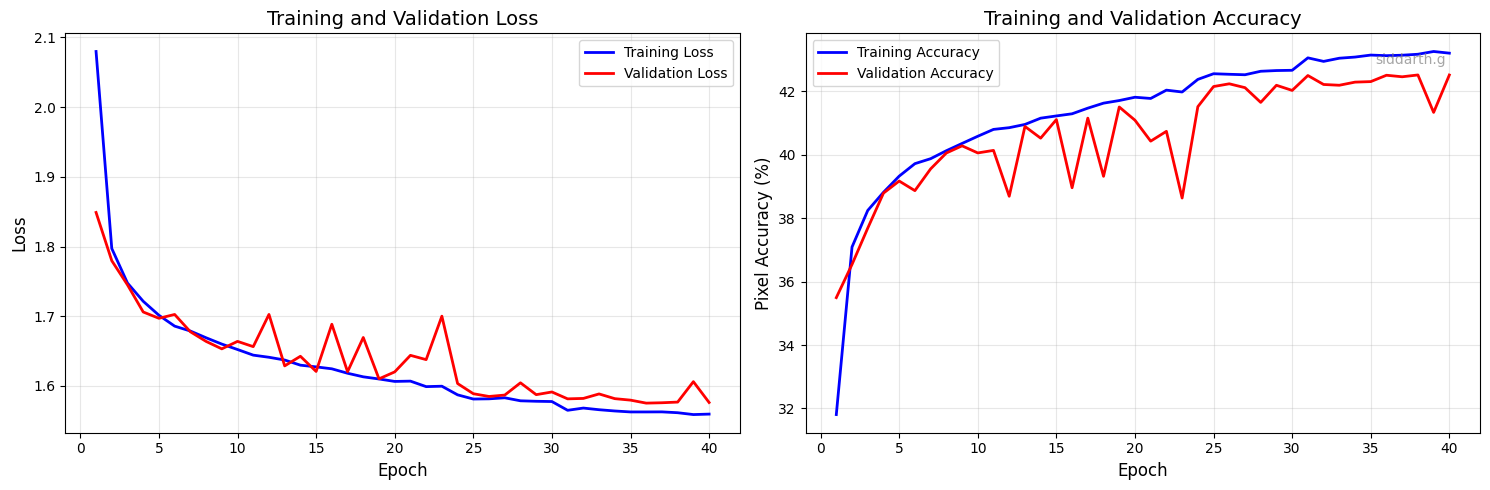


Generating colorization examples...


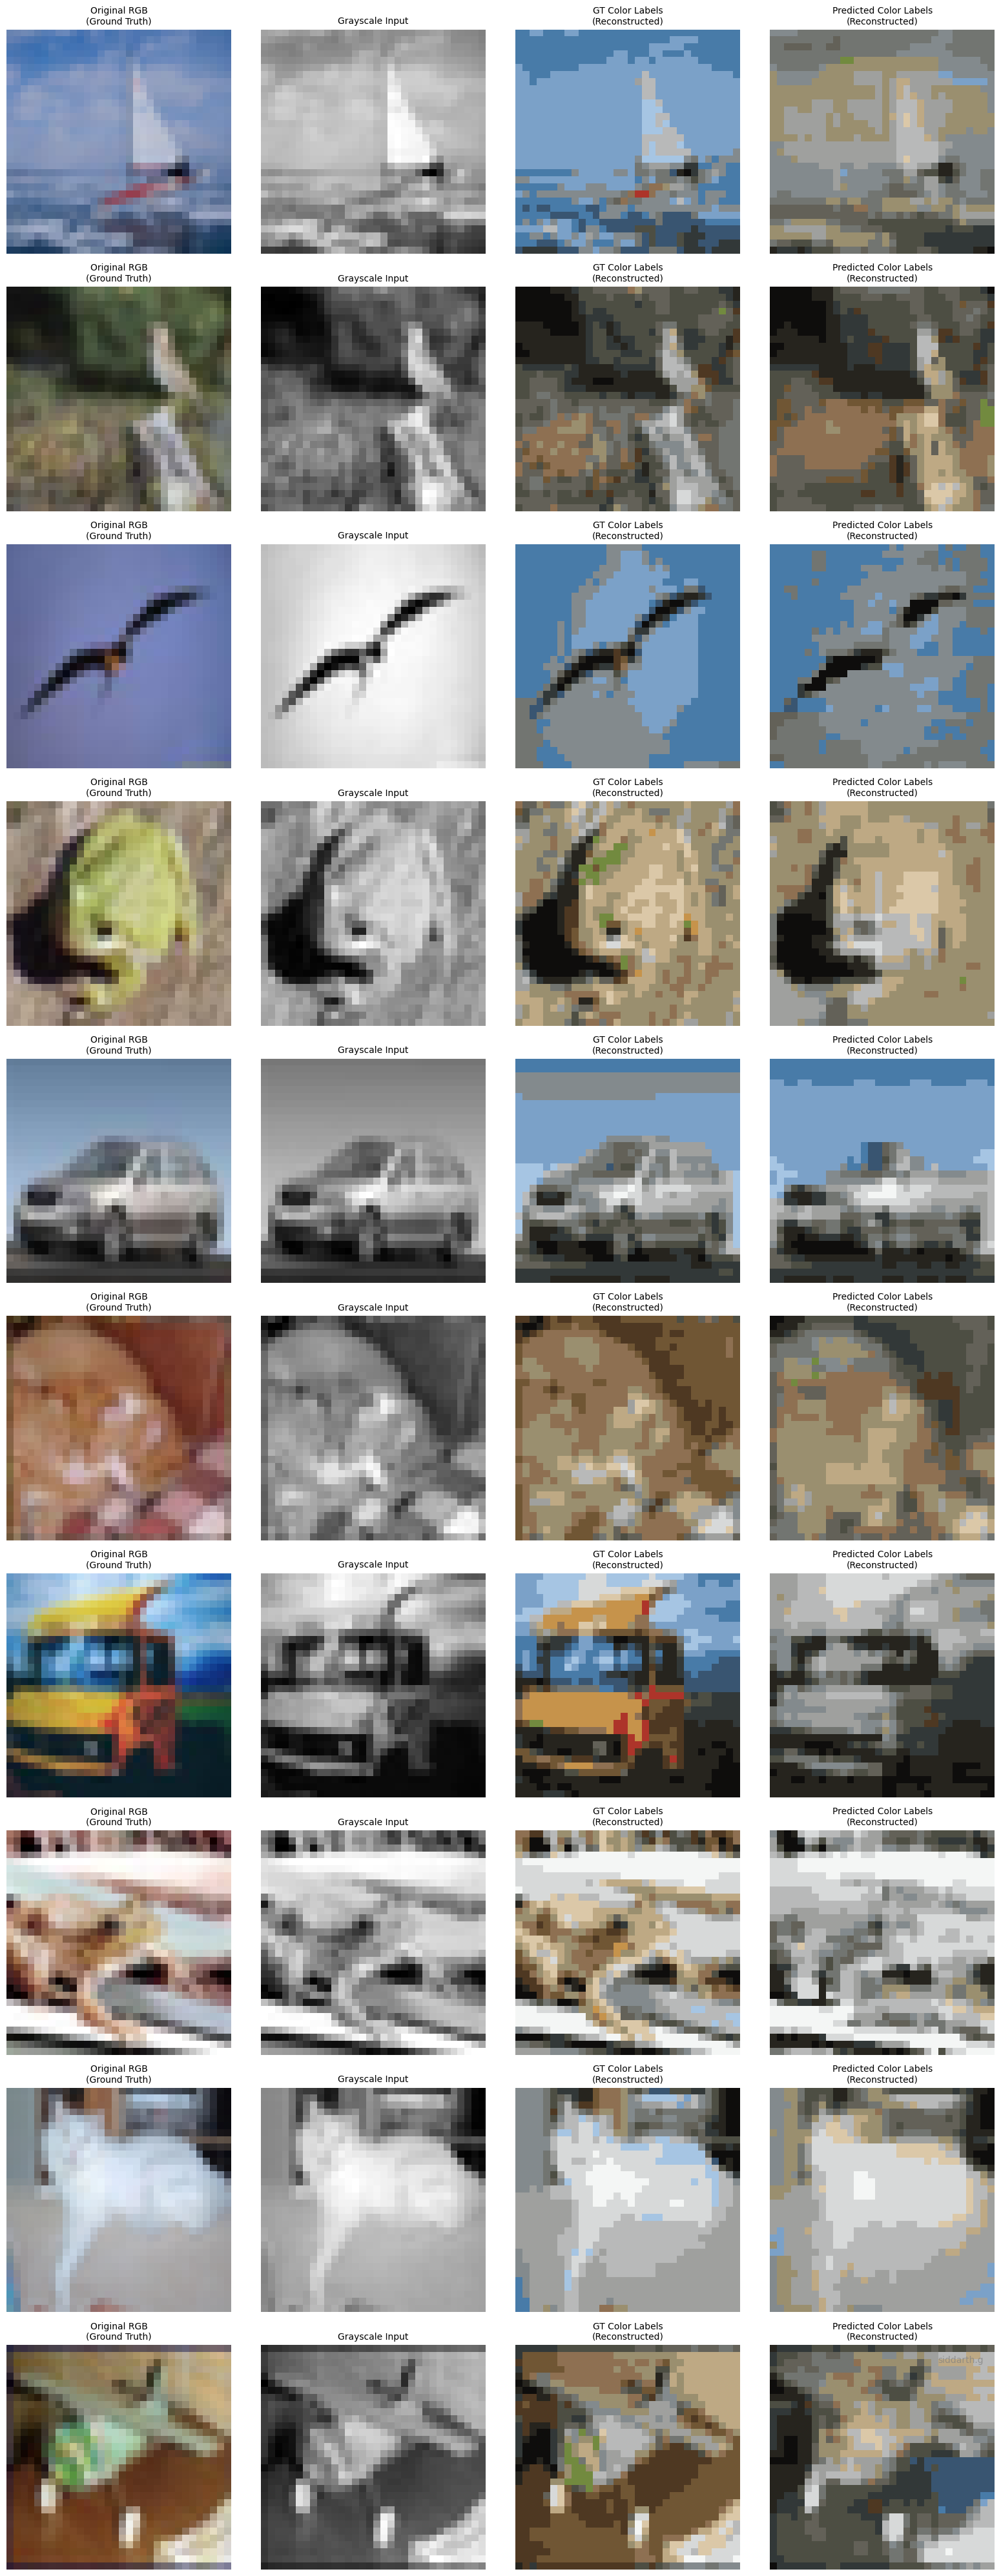

best_val_loss,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,██████████████████████▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▂▁
test_accuracy,▁
test_loss,▁
train_accuracy,▁▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
train_loss,█▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▂▃▄▅▄▅▆▆▆▆▄▆▆▇▄▇▅▇▇▆▆▄▇███▇██████████▇█
val_loss,█▆▅▄▄▄▄▃▃▃▃▄▂▃▂▄▂▃▂▂▃▃▄▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▂▁
best_val_loss,1.57541
epoch,40


In [14]:
# Train baseline model - To test before we start the sweep
print("Starting baseline training...")
baseline_results = train_model(config, run_name="baseline_NF16_LR0.001")

### WandB Sweep Setup

In [15]:
# Define sweep configuration for wandb
sweep_config = {
    'method': 'bayes', # Can be set to 'grid', 'random', or 'bayes'
    'name': 'cifar10-colorization-sweep',
    'metric': {
        'name': 'val_loss',
        'goal': 'minimize'
    },
    'parameters': {
        'learning_rate': {
            'values': [1e-4, 3e-4, 1e-3, 3e-3]
        },
        'batch_size': {
            'values': [32, 64, 128]
        },
        'NF': {
            'values': [8, 16, 32]
        },
        'kernel_size': {
            'values': [3, 5]
        },
        'optimizer': {
            'values': ['Adam', 'SGD']
        },
        'NIC': {'value': 1},
        'NC': {'value': 24},
        'epochs': {'value': 40},
        'username': {'value': 'siddarth.g'}
    }
}

print(f"Total configurations: {4 * 3 * 3 * 2 * 2}")

Total configurations: 144


In [16]:
def train_sweep():
    """
    Training function for wandb sweep
    Modified to save best model with accuracy in filename and delete older models
    """
    # Initialize wandb run
    run = wandb.init()

    config_sweep = wandb.config

    # Convert config to dictionary
    config_dict = {
        'architecture': 'ColorizationCNN',
        'NIC': config_sweep.NIC,
        'NF': config_sweep.NF,
        'NC': config_sweep.NC,
        'batch_size': config_sweep.batch_size,
        'learning_rate': config_sweep.learning_rate,
        'optimizer': config_sweep.optimizer,
        'epochs': config_sweep.epochs,
        'kernel_size': config_sweep.kernel_size,
        'username': config_sweep.username
    }

    # Create q2_models directory if it doesn't exist
    os.makedirs('q2_models', exist_ok=True)

    # Create dataloaders with sweep batch size and num_workers=4
    train_loader_sweep = DataLoader(
        train_color_dataset,
        batch_size=config_dict['batch_size'],
        shuffle=True,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )

    val_loader_sweep = DataLoader(
        val_color_dataset,
        batch_size=config_dict['batch_size'],
        shuffle=False,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )

    # Create model with sweep parameters
    model = ColorizationCNN(
        NIC=config_dict['NIC'],
        NF=config_dict['NF'],
        NC=config_dict['NC'],
        kernel_size=config_dict['kernel_size']
    ).to(device)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()

    if config_dict['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config_dict['learning_rate'])
    elif config_dict['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=config_dict['learning_rate'], momentum=0.9)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=config_dict['learning_rate'])

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=False)

    # Training loop
    best_val_loss = float('inf')
    best_val_acc = 0.0
    current_model_path = None

    for epoch in range(config_dict['epochs']):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader_sweep, criterion, optimizer, device)

        # Validate
        val_loss, val_acc = evaluate(model, val_loader_sweep, criterion, device)

        # Update learning rate
        scheduler.step(val_loss)

        # Log to wandb
        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_accuracy': train_acc,
            'val_loss': val_loss,
            'val_accuracy': val_acc,
            'learning_rate': optimizer.param_groups[0]['lr']
        })

        # Save best model with accuracy in filename
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc

            # Delete previous model if exists
            if current_model_path is not None and os.path.exists(current_model_path):
                os.remove(current_model_path)

            # Create new model filename with accuracy
            model_name = f'best_model_acc{val_acc:.2f}.pth'
            current_model_path = os.path.join('q2_models', model_name)

            # Save new best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
                'config': config_dict
            }, current_model_path)

    # Log best validation loss and accuracy
    wandb.log({'best_val_loss': best_val_loss, 'best_val_acc': best_val_acc})

    run.finish()

In [17]:
# Initialize sweep
sweep_id = wandb.sweep(sweep_config, project="q2-cifar10-colorization")

print(f"Sweep ID: {sweep_id}")
print("Starting hyperparameter sweep...")

# Run sweep
# Count parameter: number of runs
wandb.agent(sweep_id, train_sweep, count=35)  # Run 35 configurations

print("Sweep completed")

Create sweep with ID: enen36wa
Sweep URL: https://wandb.ai/iamsid44-iiit-hyderabad/q2-cifar10-colorization/sweeps/enen36wa
Sweep ID: enen36wa
Starting hyperparameter sweep...


wandb: Agent Starting Run: xi20aiqm with config:
wandb: 	NC: 24
wandb: 	NF: 8
wandb: 	NIC: 1
wandb: 	batch_size: 64
wandb: 	epochs: 40
wandb: 	kernel_size: 5
wandb: 	learning_rate: 0.0001
wandb: 	optimizer: Adam
wandb: 	username: siddarth.g


best_val_acc,▁
best_val_loss,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▄▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████████████
train_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇████████████████
val_loss,█▆▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,37.9435
best_val_loss,1.74083
epoch,40


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: iglx7bf8 with config:
wandb: 	NC: 24
wandb: 	NF: 8
wandb: 	NIC: 1
wandb: 	batch_size: 64
wandb: 	epochs: 40
wandb: 	kernel_size: 3
wandb: 	learning_rate: 0.001
wandb: 	optimizer: SGD
wandb: 	username: siddarth.g


best_val_acc,▁
best_val_loss,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▂▂▃▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████
train_loss,█▆▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▂▂▃▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█▇███████████████
val_loss,█▇▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,31.60309
best_val_loss,2.01534
epoch,40


...

wandb: Agent Starting Run: qxebwhsf with config:
wandb: 	NC: 24
wandb: 	NF: 32
wandb: 	NIC: 1
wandb: 	batch_size: 128
wandb: 	epochs: 40
wandb: 	kernel_size: 5
wandb: 	learning_rate: 0.001
wandb: 	optimizer: Adam
wandb: 	username: siddarth.g


best_val_acc,▁
best_val_loss,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,█████████████████▄▄▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▁▁▁▁▁▁
train_accuracy,▁▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇█████████████████
train_loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▄▄▅▆▆▅▅▆▆▆▆▇▆▇▆▆▆▇▇▇▇▇▇██▇▇▇███▇██████
val_loss,█▆▅▅▃▃▃▃▄▃▃▃▃▂▃▂▃▂▂▂▂▂▂▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁
best_val_acc,49.3068
best_val_loss,1.34209
epoch,40


wandb: Agent Starting Run: dxi87902 with config:
wandb: 	NC: 24
wandb: 	NF: 32
wandb: 	NIC: 1
wandb: 	batch_size: 64
wandb: 	epochs: 40
wandb: 	kernel_size: 5
wandb: 	learning_rate: 0.001
wandb: 	optimizer: Adam
wandb: 	username: siddarth.g


best_val_acc,▁
best_val_loss,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,█████████████████▄▄▄▄▄▄▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
train_accuracy,▁▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████████████
train_loss,█▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▂▂▄▄▄▅▄▃▅▅▃▃▅▄▅▅▄▆▇▅▇▇▆▇▇▇██▇▇█████████
val_loss,█▇▇▅▅▅▄▄▅▄▄▅▅▃▄▄▄▄▃▂▃▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁
best_val_acc,49.45957
best_val_loss,1.33893
epoch,40


Sweep completed


### Final Model Evaluation

In [18]:
def compute_topk_accuracy(model, dataloader, device, k_values=[1, 3, 5, 10, 15]):
    """
    Compute top-k pixel accuracy for various k values
    
    Args:
        model: Trained model
        dataloader: DataLoader to evaluate on
        device: Device to run on
        k_values: List of k values for top-k accuracy
    
    Returns:
        Dictionary mapping k to top-k accuracy
    """
    model.eval()
    topk_correct = {k: 0 for k in k_values}
    total_pixels = 0
    
    with torch.no_grad():
        for gray_imgs, color_labels, _ in dataloader:
            gray_imgs = gray_imgs.to(device)
            color_labels = color_labels.to(device).long()
            
            # Forward pass
            logits = model(gray_imgs)  # [B, 24, 32, 32]
            
            # Reshape for easier processing
            B, C, H, W = logits.shape
            logits_flat = logits.permute(0, 2, 3, 1).reshape(-1, C)  # [B*H*W, 24]
            labels_flat = color_labels.reshape(-1)  # [B*H*W]
            
            # Get top-k predictions for each k
            for k in k_values:
                _, topk_preds = torch.topk(logits_flat, k, dim=1)  # [B*H*W, k]
                
                # Check if true label is in top-k predictions
                correct = torch.any(topk_preds == labels_flat.unsqueeze(1), dim=1)
                topk_correct[k] += correct.sum().item()
            
            total_pixels += labels_flat.numel()
    
    # Compute accuracies
    topk_accuracies = {k: 100.0 * topk_correct[k] / total_pixels for k in k_values}
    
    return topk_accuracies

In [19]:
# Find the best model file (highest accuracy)
model_files = glob.glob('q2_models/best_model_acc*.pth')

if len(model_files) == 0:
    print("No model found in q2_models directory!")
else:
    # Extract accuracies from filenames and find the best one
    best_model_path = max(model_files, key=lambda x: float(x.split('acc')[1].split('.pth')[0]))
    
    print_separator()
    print("LOADING BEST MODEL")
    print_separator()
    print(f"Model path: {best_model_path}")
    
    # Load checkpoint
    checkpoint = torch.load(best_model_path)
    config_best = checkpoint['config']
    
    # Display hyperparameters
    print("\nHyperparameters:")
    print(f"  Architecture: {config_best['architecture']}")
    print(f"  Number of Input Channels (NIC): {config_best['NIC']}")
    print(f"  Number of Filters (NF): {config_best['NF']}")
    print(f"  Number of Color Classes (NC): {config_best['NC']}")
    print(f"  Kernel Size: {config_best['kernel_size']}")
    print(f"  Batch Size: {config_best['batch_size']}")
    print(f"  Learning Rate: {config_best['learning_rate']}")
    print(f"  Optimizer: {config_best['optimizer']}")
    print(f"  Epochs: {config_best['epochs']}")
    
    # Create model and load weights
    best_model = ColorizationCNN(
        NIC=config_best['NIC'],
        NF=config_best['NF'],
        NC=config_best['NC'],
        kernel_size=config_best['kernel_size']
    ).to(device)
    
    best_model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"\nModel Parameters: {best_model.count_parameters():,}")
    print(f"Best Validation Loss: {checkpoint['val_loss']:.4f}")
    print(f"Best Validation Accuracy: {checkpoint['val_acc']:.2f}%")
    
    print_separator()
    print("EVALUATING ON ALL SPLITS")
    print_separator()
    
    # Evaluate on all datasets
    criterion = nn.CrossEntropyLoss()
    
    # Train set evaluation
    print("\nEvaluating on training set...")
    train_loss, train_acc = evaluate(best_model, train_loader, criterion, device)
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Training Accuracy: {train_acc:.2f}%")
    
    # Validation set evaluation
    print("\nEvaluating on validation set...")
    val_loss, val_acc = evaluate(best_model, val_loader, criterion, device)
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    
    # Test set evaluation
    print("\nEvaluating on test set...")
    test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    
    print_separator()
    print("TOP-K ACCURACIES")
    print_separator()
    
    # Compute top-k accuracies for test set
    k_values = [1, 3, 5, 10, 15]
    print("\nComputing top-k accuracies on test set...")
    topk_accs = compute_topk_accuracy(best_model, test_loader, device, k_values)
    
    print("\nTop-K Pixel Accuracies:")
    for k, acc in topk_accs.items():
        print(f"  Top-{k:2d}: {acc:.2f}%")
    
    print_separator()
    print("RESULTS SUMMARY")
    print_separator()
    print(f"\nTrain Accuracy:      {train_acc:.2f}%")
    print(f"Validation Accuracy: {val_acc:.2f}%")
    print(f"Test Accuracy:       {test_acc:.2f}%")

LOADING BEST MODEL
Model path: q2_models/best_model_acc49.79.pth

Hyperparameters:
  Architecture: ColorizationCNN
  Number of Input Channels (NIC): 1
  Number of Filters (NF): 32
  Number of Color Classes (NC): 24
  Kernel Size: 5
  Batch Size: 128
  Learning Rate: 0.003
  Optimizer: Adam
  Epochs: 40

Model Parameters: 302,464
Best Validation Loss: 1.3284
Best Validation Accuracy: 49.79%
EVALUATING ON ALL SPLITS

Evaluating on training set...
Training Loss: 1.3164
Training Accuracy: 50.53%

Evaluating on validation set...
Validation Loss: 1.3284
Validation Accuracy: 49.79%

Evaluating on test set...
Test Loss: 1.3263
Test Accuracy: 49.91%
TOP-K ACCURACIES

Computing top-k accuracies on test set...

Top-K Pixel Accuracies:
  Top- 1: 49.91%
  Top- 3: 85.02%
  Top- 5: 95.14%
  Top-10: 99.74%
  Top-15: 99.99%
RESULTS SUMMARY

Train Accuracy:      50.53%
Validation Accuracy: 49.79%
Test Accuracy:       49.91%


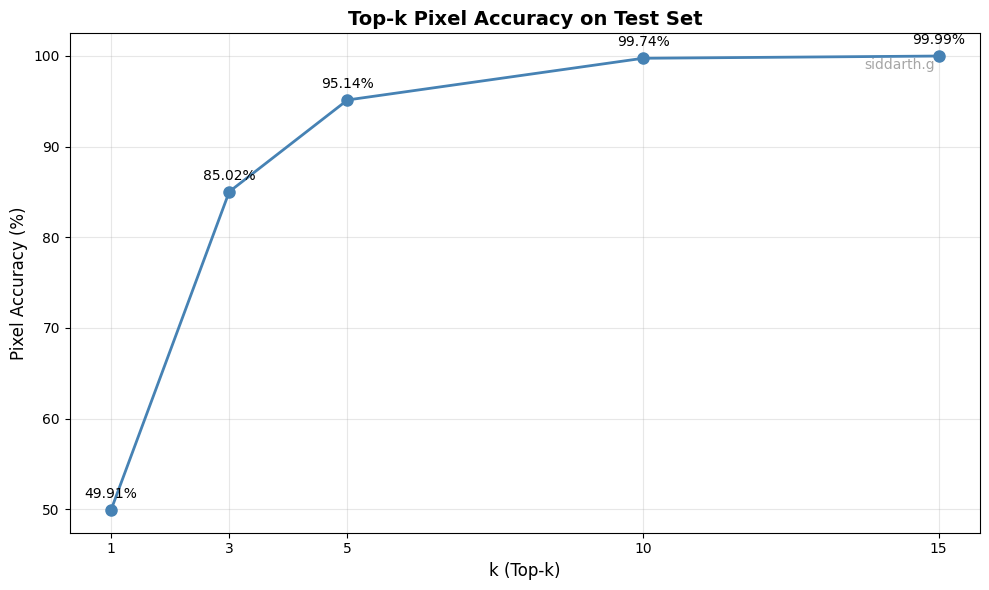

In [20]:
# Visualize top-k accuracy plot
fig, ax = plt.subplots(figsize=(10, 6))

k_list = list(topk_accs.keys())
acc_list = list(topk_accs.values())

ax.plot(k_list, acc_list, 'o-', linewidth=2, markersize=8, color='steelblue')
ax.set_xlabel('k (Top-k)', fontsize=12)
ax.set_ylabel('Pixel Accuracy (%)', fontsize=12)
ax.set_title('Top-k Pixel Accuracy on Test Set', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(k_list)

# Add value labels on points
for k, acc in zip(k_list, acc_list):
    ax.text(k, acc + 1, f'{acc:.2f}%', ha='center', va='bottom', fontsize=10)

add_username("siddarth.g")
plt.tight_layout()
plt.savefig('topk_accuracy_plot.png', dpi=150, bbox_inches='tight')
plt.show()

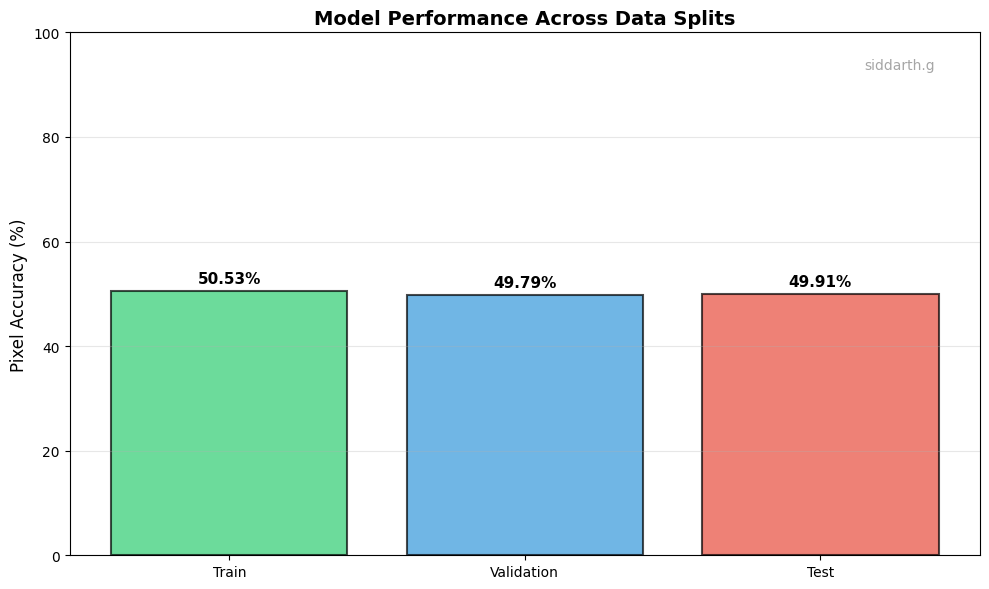

In [21]:
# Visualize accuracy comparison across splits
fig, ax = plt.subplots(figsize=(10, 6))

splits = ['Train', 'Validation', 'Test']
accuracies = [train_acc, val_acc, test_acc]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(splits, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Pixel Accuracy (%)', fontsize=12)
ax.set_title('Model Performance Across Data Splits', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

add_username("siddarth.g")
plt.tight_layout()
plt.savefig('split_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Generating colorization examples with the best model...


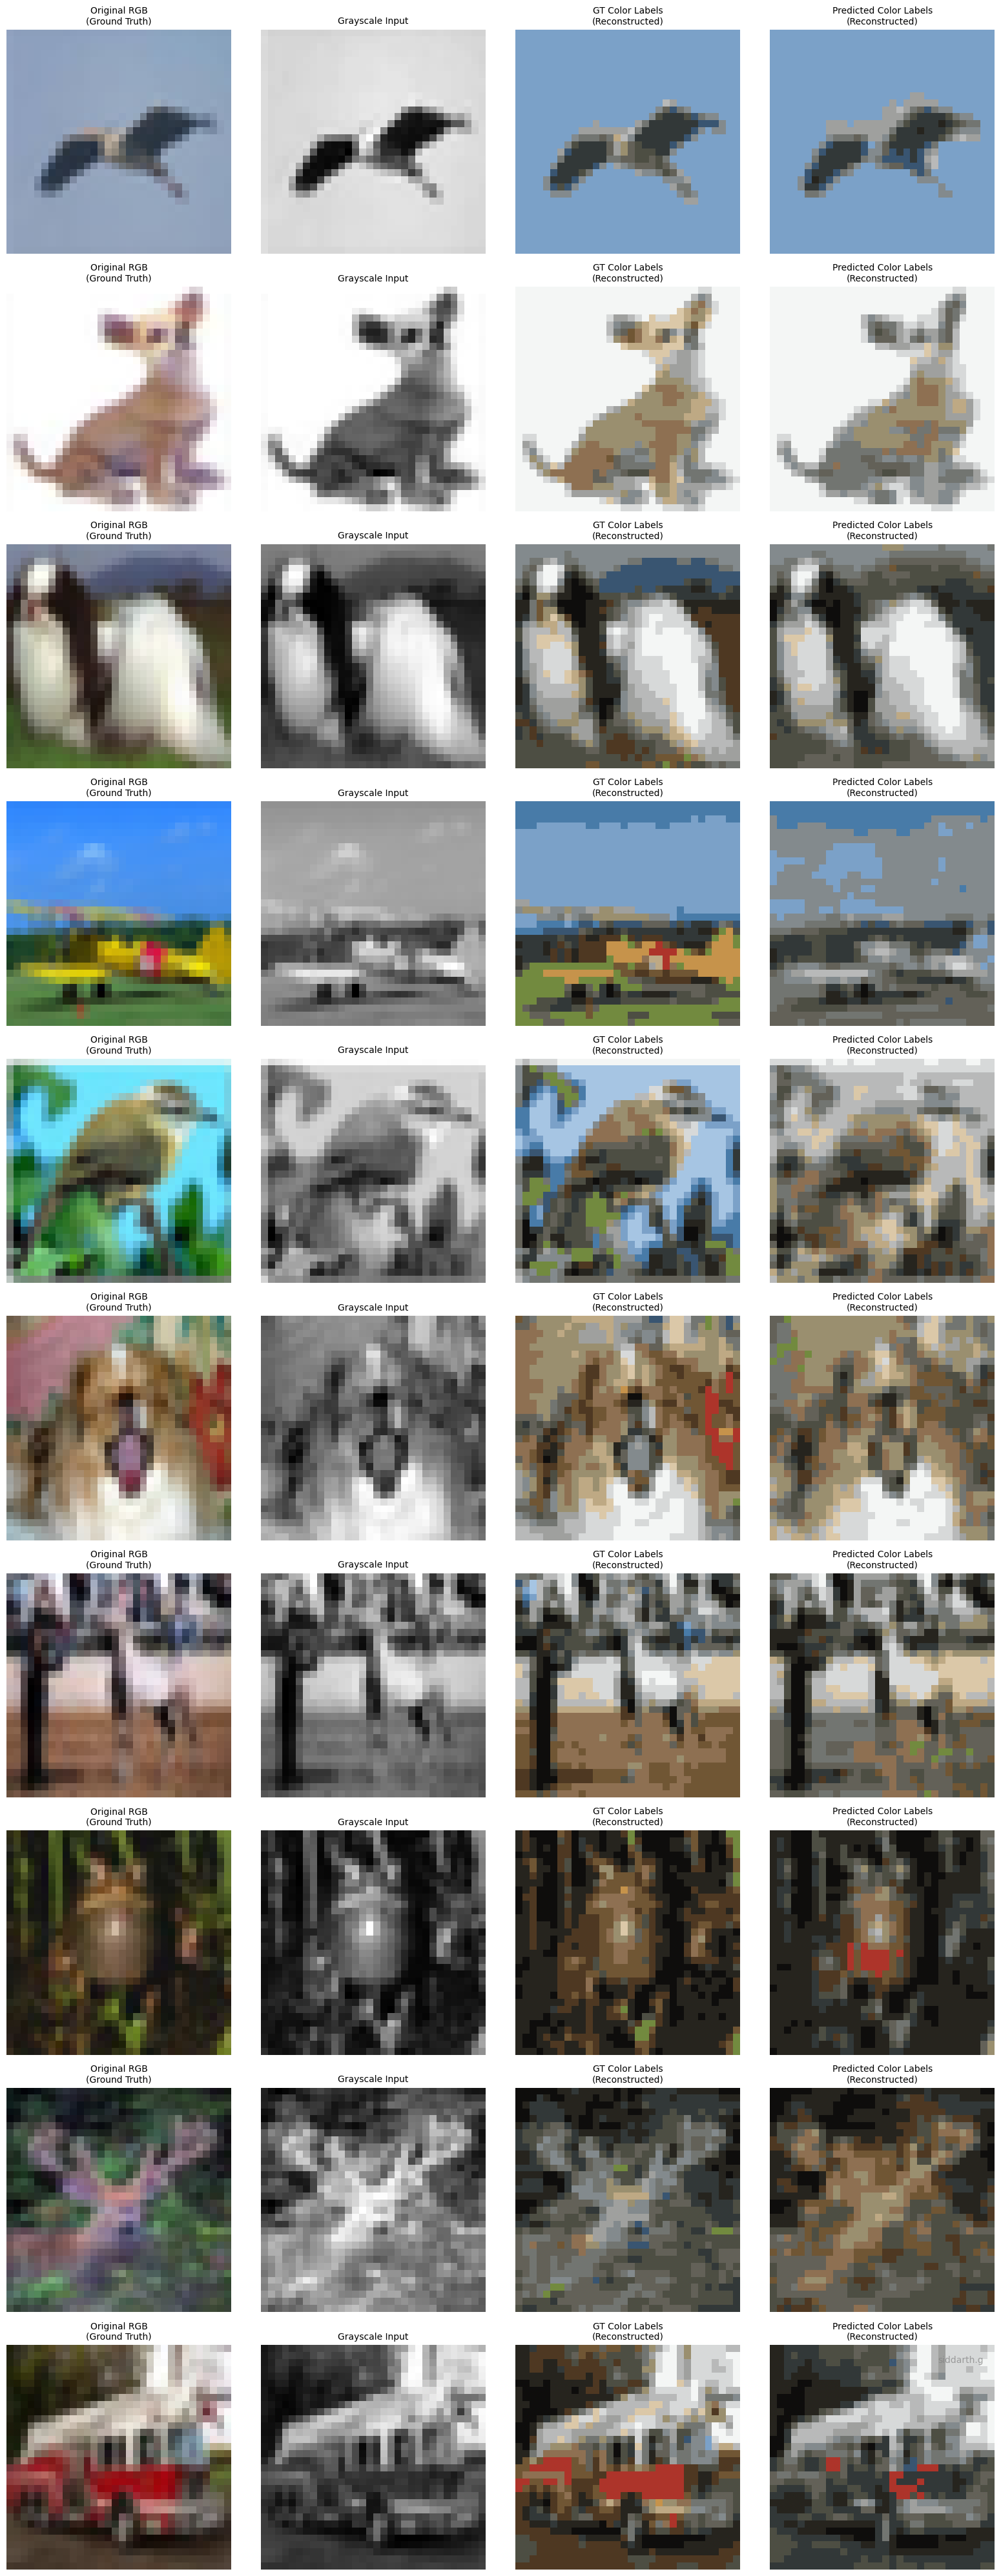

In [22]:
# Generate colorization examples with the best model
print("Generating colorization examples with the best model...")
visualize_colorization(best_model, test_color_dataset, color_centroids, device, n_samples=10)

In [23]:
def compute_model_statistics(NIC=1, NF=16, NC=24, input_size=32):
    """
    Compute number of weights, outputs, and connections for the model
    
    Args:
        NIC: Number of input channels
        NF: Number of filters in first layer
        NC: Number of color classes (output channels)
        input_size: Input spatial size (32 for CIFAR-10)
    """
    
    print_separator()
    print(f"Model Statistics for Input Size: {input_size}x{input_size}")
    print_separator()
    
    # Encoder 1: Conv2d(NIC -> NF, k=3) + MaxPool
    # Conv layer
    weights_e1_conv = NIC * NF * 3 * 3
    outputs_e1_conv = NF * input_size * input_size
    connections_e1_conv = weights_e1_conv * outputs_e1_conv
    
    # After pooling
    size_after_e1 = input_size // 2
    outputs_e1_pool = NF * size_after_e1 * size_after_e1
    
    print(f"\nEncoder 1:")
    print(f"  Conv2d({NIC} -> {NF}, kernel=3x3):")
    print(f"    Weights: {NIC} * {NF} * 3 * 3 = {weights_e1_conv}")
    print(f"    Outputs: {NF} * {input_size} * {input_size} = {outputs_e1_conv}")
    print(f"    Connections: {weights_e1_conv} * {outputs_e1_conv} = {connections_e1_conv:,}")
    print(f"  After MaxPool: {NF} * {size_after_e1} * {size_after_e1} = {outputs_e1_pool}")
    
    # Encoder 2: Conv2d(NF -> 2*NF, k=3) + MaxPool
    weights_e2_conv = NF * (2*NF) * 3 * 3
    outputs_e2_conv = (2*NF) * size_after_e1 * size_after_e1
    connections_e2_conv = weights_e2_conv * outputs_e2_conv
    
    size_after_e2 = size_after_e1 // 2
    outputs_e2_pool = (2*NF) * size_after_e2 * size_after_e2
    
    print(f"\nEncoder 2:")
    print(f"  Conv2d({NF} -> {2*NF}, kernel=3x3):")
    print(f"    Weights: {NF} * {2*NF} * 3 * 3 = {weights_e2_conv}")
    print(f"    Outputs: {2*NF} * {size_after_e1} * {size_after_e1} = {outputs_e2_conv}")
    print(f"    Connections: {weights_e2_conv} * {outputs_e2_conv} = {connections_e2_conv:,}")
    print(f"  After MaxPool: {2*NF} * {size_after_e2} * {size_after_e2} = {outputs_e2_pool}")
    
    # Encoder 3: Conv2d(2*NF -> 4*NF, k=3) + MaxPool
    weights_e3_conv = (2*NF) * (4*NF) * 3 * 3
    outputs_e3_conv = (4*NF) * size_after_e2 * size_after_e2
    connections_e3_conv = weights_e3_conv * outputs_e3_conv
    
    size_after_e3 = size_after_e2 // 2
    outputs_e3_pool = (4*NF) * size_after_e3 * size_after_e3
    
    print(f"\nEncoder 3:")
    print(f"  Conv2d({2*NF} -> {4*NF}, kernel=3x3):")
    print(f"    Weights: {2*NF} * {4*NF} * 3 * 3 = {weights_e3_conv}")
    print(f"    Outputs: {4*NF} * {size_after_e2} * {size_after_e2} = {outputs_e3_conv}")
    print(f"    Connections: {weights_e3_conv} * {outputs_e3_conv} = {connections_e3_conv:,}")
    print(f"  After MaxPool: {4*NF} * {size_after_e3} * {size_after_e3} = {outputs_e3_pool}")
    
    # Decoder 1: ConvTranspose2d(4*NF -> 2*NF, k=2, s=2)
    weights_d1 = (4*NF) * (2*NF) * 2 * 2
    size_after_d1 = size_after_e3 * 2
    outputs_d1 = (2*NF) * size_after_d1 * size_after_d1
    connections_d1 = weights_d1 * outputs_d1
    
    print(f"\nDecoder 1:")
    print(f"  ConvTranspose2d({4*NF} -> {2*NF}, kernel=2x2, stride=2):")
    print(f"    Weights: {4*NF} * {2*NF} * 2 * 2 = {weights_d1}")
    print(f"    Outputs: {2*NF} * {size_after_d1} * {size_after_d1} = {outputs_d1}")
    print(f"    Connections: {weights_d1} * {outputs_d1} = {connections_d1:,}")
    
    # Decoder 2: ConvTranspose2d(2*NF -> NF, k=2, s=2)
    weights_d2 = (2*NF) * NF * 2 * 2
    size_after_d2 = size_after_d1 * 2
    outputs_d2 = NF * size_after_d2 * size_after_d2
    connections_d2 = weights_d2 * outputs_d2
    
    print(f"\nDecoder 2:")
    print(f"  ConvTranspose2d({2*NF} -> {NF}, kernel=2x2, stride=2):")
    print(f"    Weights: {2*NF} * {NF} * 2 * 2 = {weights_d2}")
    print(f"    Outputs: {NF} * {size_after_d2} * {size_after_d2} = {outputs_d2}")
    print(f"    Connections: {weights_d2} * {outputs_d2} = {connections_d2:,}")
    
    # Decoder 3: ConvTranspose2d(NF -> NC, k=2, s=2)
    weights_d3 = NF * NC * 2 * 2
    size_after_d3 = size_after_d2 * 2
    outputs_d3 = NC * size_after_d3 * size_after_d3
    connections_d3 = weights_d3 * outputs_d3
    
    print(f"\nDecoder 3:")
    print(f"  ConvTranspose2d({NF} -> {NC}, kernel=2x2, stride=2):")
    print(f"    Weights: {NF} * {NC} * 2 * 2 = {weights_d3}")
    print(f"    Outputs: {NC} * {size_after_d3} * {size_after_d3} = {outputs_d3}")
    print(f"    Connections: {weights_d3} * {outputs_d3} = {connections_d3:,}")
    
    # Classifier: Conv2d(NC -> NC, k=1)
    weights_classifier = NC * NC * 1 * 1
    outputs_classifier = NC * size_after_d3 * size_after_d3
    connections_classifier = weights_classifier * outputs_classifier
    
    print(f"\nClassifier:")
    print(f"  Conv2d({NC} -> {NC}, kernel=1x1):")
    print(f"    Weights: {NC} * {NC} * 1 * 1 = {weights_classifier}")
    print(f"    Outputs: {NC} * {size_after_d3} * {size_after_d3} = {outputs_classifier}")
    print(f"    Connections: {weights_classifier} * {outputs_classifier} = {connections_classifier:,}")
    
    # Totals
    total_weights = (weights_e1_conv + weights_e2_conv + weights_e3_conv + 
                     weights_d1 + weights_d2 + weights_d3 + weights_classifier)
    
    total_outputs = (outputs_e1_conv + outputs_e1_pool + outputs_e2_conv + outputs_e2_pool +
                     outputs_e3_conv + outputs_e3_pool + outputs_d1 + outputs_d2 + 
                     outputs_d3 + outputs_classifier)
    
    total_connections = (connections_e1_conv + connections_e2_conv + connections_e3_conv +
                         connections_d1 + connections_d2 + connections_d3 + connections_classifier)
    
    print_separator()
    print("TOTALS:")
    print(f"Total Weights: {total_weights:,}")
    print(f"Total Outputs: {total_outputs:,}")
    print(f"Total Connections: {total_connections:,}")
    print_separator()
    
    return {
        'total_weights': total_weights,
        'total_outputs': total_outputs,
        'total_connections': total_connections
    }

# Compute for 32x32 input
print("\nStatistics for 32x32 input (CIFAR-10)")
stats_32 = compute_model_statistics(NIC=1, NF=16, NC=24, input_size=32)

# print("\nStatistics for 64x64 input")
# stats_64 = compute_model_statistics(NIC=1, NF=16, NC=24, input_size=64)


Statistics for 32x32 input (CIFAR-10)
Model Statistics for Input Size: 32x32

Encoder 1:
  Conv2d(1 -> 16, kernel=3x3):
    Weights: 1 * 16 * 3 * 3 = 144
    Outputs: 16 * 32 * 32 = 16384
    Connections: 144 * 16384 = 2,359,296
  After MaxPool: 16 * 16 * 16 = 4096

Encoder 2:
  Conv2d(16 -> 32, kernel=3x3):
    Weights: 16 * 32 * 3 * 3 = 4608
    Outputs: 32 * 16 * 16 = 8192
    Connections: 4608 * 8192 = 37,748,736
  After MaxPool: 32 * 8 * 8 = 2048

Encoder 3:
  Conv2d(32 -> 64, kernel=3x3):
    Weights: 32 * 64 * 3 * 3 = 18432
    Outputs: 64 * 8 * 8 = 4096
    Connections: 18432 * 4096 = 75,497,472
  After MaxPool: 64 * 4 * 4 = 1024

Decoder 1:
  ConvTranspose2d(64 -> 32, kernel=2x2, stride=2):
    Weights: 64 * 32 * 2 * 2 = 8192
    Outputs: 32 * 8 * 8 = 2048
    Connections: 8192 * 2048 = 16,777,216

Decoder 2:
  ConvTranspose2d(32 -> 16, kernel=2x2, stride=2):
    Weights: 32 * 16 * 2 * 2 = 2048
    Outputs: 16 * 16 * 16 = 4096
    Connections: 2048 * 4096 = 8,388,608

Decoder